# <div style="text-align: center;">Predict Calorie Expenditure</div> 
<div style="text-align: center;"><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ9bkhJ_KqgXGpdHwV6CC-SduGodHVXeKruAQ&s"width=400 style"></div>

In this project, we will develop a machine learning model to predict how many calories were burned during a workout using regression algorithms. The evaluation metric for this competition is Root Mean Squared Logarithmic Error (RMSLE). 

The dataset contains: 

* Features: id, Sex, Age, Height, Weight, Duration, Heart_rate, Body_temp
* Target: Calories

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Reading Dataset

In [2]:
df_train = pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv')
submission = pd.read_csv('/kaggle/input/playground-series-s5e5/sample_submission.csv')

## EDA

In [3]:
df_train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
df_train.shape

(750000, 9)

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [6]:
df_train.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [7]:
df_test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


In [8]:
df_test.shape

(250000, 8)

In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 15.3+ MB


In [10]:
df_test.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64

In [11]:
submission.head()

,id,Calories
0,750000,88.283
1,750001,88.283
2,750002,88.283
3,750003,88.283
4,750004,88.283


In [12]:
df_train.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [13]:
train = df_train.drop('id', axis=1).copy()

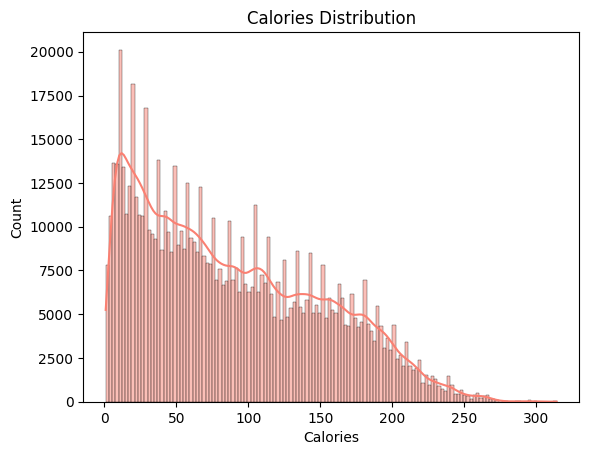

In [14]:
sns.histplot(train['Calories'], kde=True, color='salmon')
plt.title('Calories Distribution');

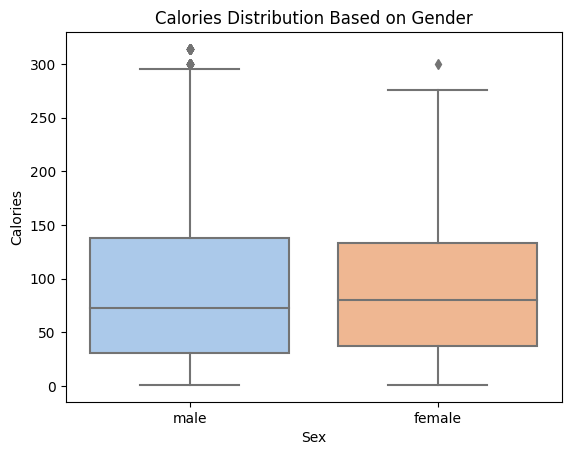

In [15]:
sns.boxplot(x=train['Sex'], y=train['Calories'], palette='pastel')
plt.title('Calories Distribution Based on Gender');

In [16]:
train['Sex'] = train['Sex'].map({'male': 0,'female': 1})

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  int64  
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 45.8 MB


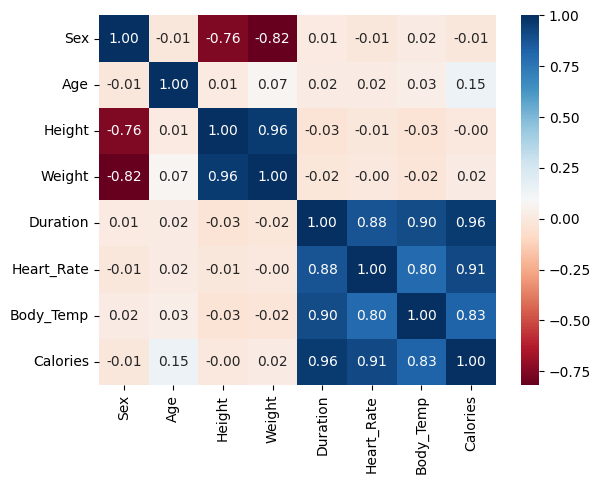

In [18]:
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap='RdBu');

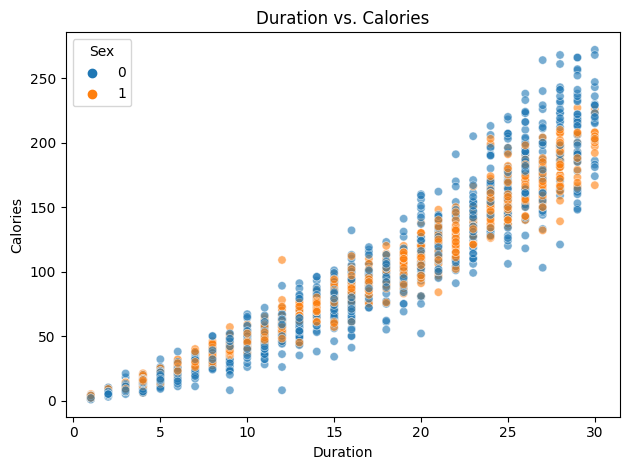

In [19]:
sns.scatterplot(data=train.sample(2000), x='Duration', y='Calories', hue='Sex', alpha=0.6, cmap='plasma')
plt.title('Duration vs. Calories')
plt.tight_layout();

## Feature Engineering

In [20]:
#Body Mass Index
train["BMI"] = train["Weight"] / ((train["Height"] / 100) ** 2)
df_test["BMI"] = df_test["Weight"] / ((df_test["Height"] / 100) ** 2)

#BMR (Basal Metabolic Rate)
train['BMR'] = (10 * train['Weight']) + (6.25 * train['Height']) - (5 * train['Age'])
df_test['BMR'] = (10 * df_test['Weight']) + (6.25 * df_test['Height']) - (5 * df_test['Age'])

#Duration relative to heart rate (Effort)
train["Effort"] = train["Duration"] * train["Heart_Rate"]
df_test["Effort"] = df_test["Duration"] * df_test["Heart_Rate"]

#Temperature Difference
train['Temp_Diff'] = train['Body_Temp'] - 37.0
df_test['Temp_Diff'] = df_test['Body_Temp'] - 37.0

# Exercise intensity: interaction between heart rate and body temperature
train["Intensity"] = train["Heart_Rate"] * train["Body_Temp"]
df_test["Intensity"] = df_test["Heart_Rate"] * df_test["Body_Temp"]

# Body temperature per minute of exercise
train["Temp_per_Minute"] = train["Body_Temp"] / train["Duration"].replace(0, 1)
df_test["Temp_per_Minute"] = df_test["Body_Temp"] / df_test["Duration"].replace(0, 1)

In [21]:
train.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,BMR,Effort,Temp_Diff,Intensity,Temp_per_Minute
0,0,36,189.0,82.0,26.0,101.0,41.0,150.0,22.955684,1821.25,2626.0,4.0,4141.0,1.576923
1,1,64,163.0,60.0,8.0,85.0,39.7,34.0,22.582709,1298.75,680.0,2.7,3374.5,4.962500
2,1,51,161.0,64.0,7.0,84.0,39.8,29.0,24.690405,1391.25,588.0,2.8,3343.2,5.685714
3,0,20,192.0,90.0,25.0,105.0,40.7,140.0,24.414062,2000.00,2625.0,3.7,4273.5,1.628000
4,1,38,166.0,61.0,25.0,102.0,40.6,146.0,22.136740,1457.50,2550.0,3.6,4141.2,1.624000


In [22]:
df_test['Sex'] = df_test['Sex'].map({'male': 0,'female': 1})

In [23]:
df_test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,BMR,Effort,Temp_Diff,Intensity,Temp_per_Minute
0,750000,0,45,177.0,81.0,7.0,87.0,39.8,25.854639,1691.25,609.0,2.8,3462.6,5.685714
1,750001,0,26,200.0,97.0,20.0,101.0,40.5,24.250000,2090.00,2020.0,3.5,4090.5,2.025000
2,750002,1,29,188.0,85.0,16.0,102.0,40.4,24.049344,1880.00,1632.0,3.4,4120.8,2.525000
3,750003,1,39,172.0,73.0,20.0,107.0,40.6,24.675500,1610.00,2140.0,3.6,4344.2,2.030000
4,750004,1,30,173.0,67.0,16.0,94.0,40.5,22.386314,1601.25,1504.0,3.5,3807.0,2.531250


## Data Processing

In [24]:
x=train.drop('Calories', axis=1)
y=train['Calories']
test=df_test.drop('id', axis=1)

## Modelling

In [29]:
from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor, RandomForestRegressor
from sklearn.tree import plot_tree, ExtraTreeRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

def algo_test(x,y):
        print("Model tanımlanıyor...")
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        ada=AdaBoostRegressor()
        xgb=XGBRegressor()
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'AdaBoost','XGBRegressor']
    
        print("Veri ölçeklendiriliyor...")
        x=MinMaxScaler().fit_transform(x)
                
        print("Veri kümesi eğitim ve test kümelerine ayrılıyor...")
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []

        print("Sonuçları saklamak için DataFrame oluşturuluyor...")
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)


        print("Modeller eğitiliyor ve test ediliyor...")
        for algo, name in zip(algos, algo_names): 
            print(f"{name} modeli eğitiliyor...")
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
        print("Sonuçlar DataFrame'e yerleştiriliyor...")
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae

        print("Sonuçlar sıralanıyor...")
        rtable=result.sort_values('R_Squared',ascending=False)

        print("İşlem tamamlandı!")
        return rtable

In [30]:
algo_test(x,y)

Model tanımlanıyor...
Veri ölçeklendiriliyor...
Veri kümesi eğitim ve test kümelerine ayrılıyor...
Sonuçları saklamak için DataFrame oluşturuluyor...
Modeller eğitiliyor ve test ediliyor...
Linear modeli eğitiliyor...
Ridge modeli eğitiliyor...
Lasso modeli eğitiliyor...
ElasticNet modeli eğitiliyor...
SGD modeli eğitiliyor...
Extra Tree modeli eğitiliyor...
Gradient Boosting modeli eğitiliyor...
AdaBoost modeli eğitiliyor...
XGBRegressor modeli eğitiliyor...
Sonuçlar DataFrame'e yerleştiriliyor...
Sonuçlar sıralanıyor...
İşlem tamamlandı!


,R_Squared,RMSE,MAE
XGBRegressor,0.996287,3.793250,2.342578
Gradient Boosting,0.994968,4.416287,2.924468
Extra Tree,0.993113,5.166228,3.133811
Linear,0.984454,7.762137,5.537427
Ridge,0.984447,7.763830,5.533850
SGD,0.982084,8.332815,5.865231
Lasso,0.964052,11.803486,7.566889
AdaBoost,0.883849,21.216867,17.263829
ElasticNet,0.491388,44.398015,37.285714


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

def smart_algo_test():
    print("Modeller hazırlanıyor...")
    
    models = [
        ("Linear Regression", LinearRegression()),
        ("Ridge", Ridge()),
        ("XGBoost (GPU)", XGBRegressor(n_estimators=1000,learning_rate=0.05,
                                       tree_method='hist',device='cuda',random_state=42)),
        ("LightGBM (GPU)", LGBMRegressor(n_estimators=1000,learning_rate=0.05,
                                         device='gpu',random_state=42,verbose=-1)),
        ("CatBoost (GPU)", CatBoostRegressor(iterations=1000,learning_rate=0.05,
                                             task_type="GPU",devices='0',verbose=0,random_state=42))]

    results = []
    
    print(f"{'Model':<20} | {'RMSE':<10} | {'R2 Score':<10}")
    
    for name, model in models:
        try:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, preds))
            r2 = r2_score(y_test, preds)
            results.append([name, rmse, r2])
            print(f"{name:<20} | {rmse:.4f}     | {r2:.4f}")
        except Exception as e:
            print(f"{name} hatası: {str(e)}")
            
    return pd.DataFrame(results, columns=["Model", "RMSE", "R2"]).sort_values("RMSE")

In [32]:
smart_algo_test()

Modeller hazırlanıyor...
Model                | RMSE       | R2 Score  
Linear Regression    | 7.7621     | 0.9845
Ridge                | 7.7621     | 0.9845
XGBoost (GPU)        | 3.6038     | 0.9966
LightGBM (GPU)       | 3.6142     | 0.9966
CatBoost (GPU)       | 3.6151     | 0.9966


,Model,RMSE,R2
2,XGBoost (GPU),3.603797,0.996649
3,LightGBM (GPU),3.614189,0.996630
4,CatBoost (GPU),3.615059,0.996628
0,Linear Regression,7.762109,0.984454
1,Ridge,7.762110,0.984454


In [33]:
import optuna
import xgboost as xgb

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1000, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'tree_method': 'hist',
        'device': 'cuda',       
        'random_state': 42,
        'n_jobs': -1}
    
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train,eval_set=[(X_test, y_test)],verbose=False)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

print("Optuna optimizasyonu başlıyor...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) 
print("En İyi Parametreler:", study.best_params)
print("En İyi RMSE:", study.best_value)

[I 2025-12-03 12:03:49,327] A new study created in memory with name: no-name-c9ded0be-4400-430f-9dec-16cc731ba4d5


Optuna optimizasyonu başlıyor...


[I 2025-12-03 12:04:04,498] Trial 0 finished with value: 3.6231202075554836 and parameters: {'n_estimators': 2335, 'learning_rate': 0.06901509961259503, 'max_depth': 6, 'subsample': 0.9912416691640626, 'colsample_bytree': 0.9509817373111248, 'min_child_weight': 8}. Best is trial 0 with value: 3.6231202075554836.
[I 2025-12-03 12:04:27,420] Trial 1 finished with value: 3.710377162978808 and parameters: {'n_estimators': 2522, 'learning_rate': 0.09620640493732453, 'max_depth': 8, 'subsample': 0.859427320708122, 'colsample_bytree': 0.6475222502980703, 'min_child_weight': 5}. Best is trial 0 with value: 3.6231202075554836.
[I 2025-12-03 12:04:36,436] Trial 2 finished with value: 3.623122570246397 and parameters: {'n_estimators': 1190, 'learning_rate': 0.07342710447882808, 'max_depth': 7, 'subsample': 0.902479552997115, 'colsample_bytree': 0.6173123349894156, 'min_child_weight': 6}. Best is trial 0 with value: 3.6231202075554836.
[I 2025-12-03 12:04:46,037] Trial 3 finished with value: 3.658

En İyi Parametreler: {'n_estimators': 1348, 'learning_rate': 0.013113900053516404, 'max_depth': 8, 'subsample': 0.8939637965060047, 'colsample_bytree': 0.8539190344172591, 'min_child_weight': 1}
En İyi RMSE: 3.578893508017269


In [35]:
best_params = {'n_estimators': 1348,'learning_rate': 0.013113900053516404,'max_depth': 8,
               'subsample': 0.8939637965060047,'colsample_bytree': 0.8539190344172591,'min_child_weight': 1,
               'tree_method': 'hist','device': 'cuda','random_state': 42,'n_jobs': -1}

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(x, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8539190344172591, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.013113900053516404, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1348, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## Submission

In [36]:
final_preds = final_model.predict(test)

submission = pd.DataFrame()
submission['id'] = df_test['id']  
submission['Calories'] = final_preds

submission.to_csv('submission.csv', index=False)

The submission had a 0.05870 Root Mean Squared Logarithmic Error (RMSLE).

In [37]:
import joblib
import json

joblib.dump(final_model, 'xgboost_model.pkl') 

model_columns = list(x.columns)
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

## Modelling - 2

In [38]:
from catboost import CatBoostRegressor

xgb_preds = final_preds 

cat_params = {'iterations': 2000,'learning_rate': 0.05,'depth': 8,'loss_function': 'RMSE',
              'task_type': 'GPU','devices': '0','verbose': 0,'random_seed': 42}

cat_model = CatBoostRegressor(**cat_params)
cat_model.fit(x, y)

cat_preds = cat_model.predict(test)
ensemble_preds = (xgb_preds * 0.5) + (cat_preds * 0.5)

submission_ensemble = pd.DataFrame()
submission_ensemble['id'] = df_test['id']
submission_ensemble['Calories'] = ensemble_preds

submission_ensemble.to_csv('submission_v1.csv', index=False)

The submission had a 0.05864 Root Mean Squared Logarithmic Error (RMSLE).